# загрузка данных и импорт библиотек

In [30]:

import pandas as pd
import numpy as np


df = pd.read_csv('D:/Dataset/dataset_schule/df_complete/train.csv')
df_test = pd.read_csv('D:/Dataset/dataset_schule/df_complete/test.csv')

# перевод названий столбцов на русский

In [2]:
dicts = {
    'health_condition': 'состояние_здоровья',
    'sleep_duration': 'длительность_сна',
    'heart_rate': 'частота_пульса',
    'bmi': 'индекс_массы_тела',
    'calorie_expenditure': 'расход_калорий',
    'step_count': 'количество_шагов',
    'exercise_duration': 'длительность_тренировки',
    'water_intake': 'потребление_воды',
    'diet_type': 'тип_диеты',
    'stress_level': 'уровень_стресса',
    'sleep_quality': 'качество_сна',
    'physical_activity_level': 'уровень_физ_активности',
    'smoking_alcohol': 'курение_алкоголь',
    'gender': 'пол'
}
df = df.rename(columns = dicts)
df_test = df_test.rename(columns = dicts)

# смотрим корреляции между данными

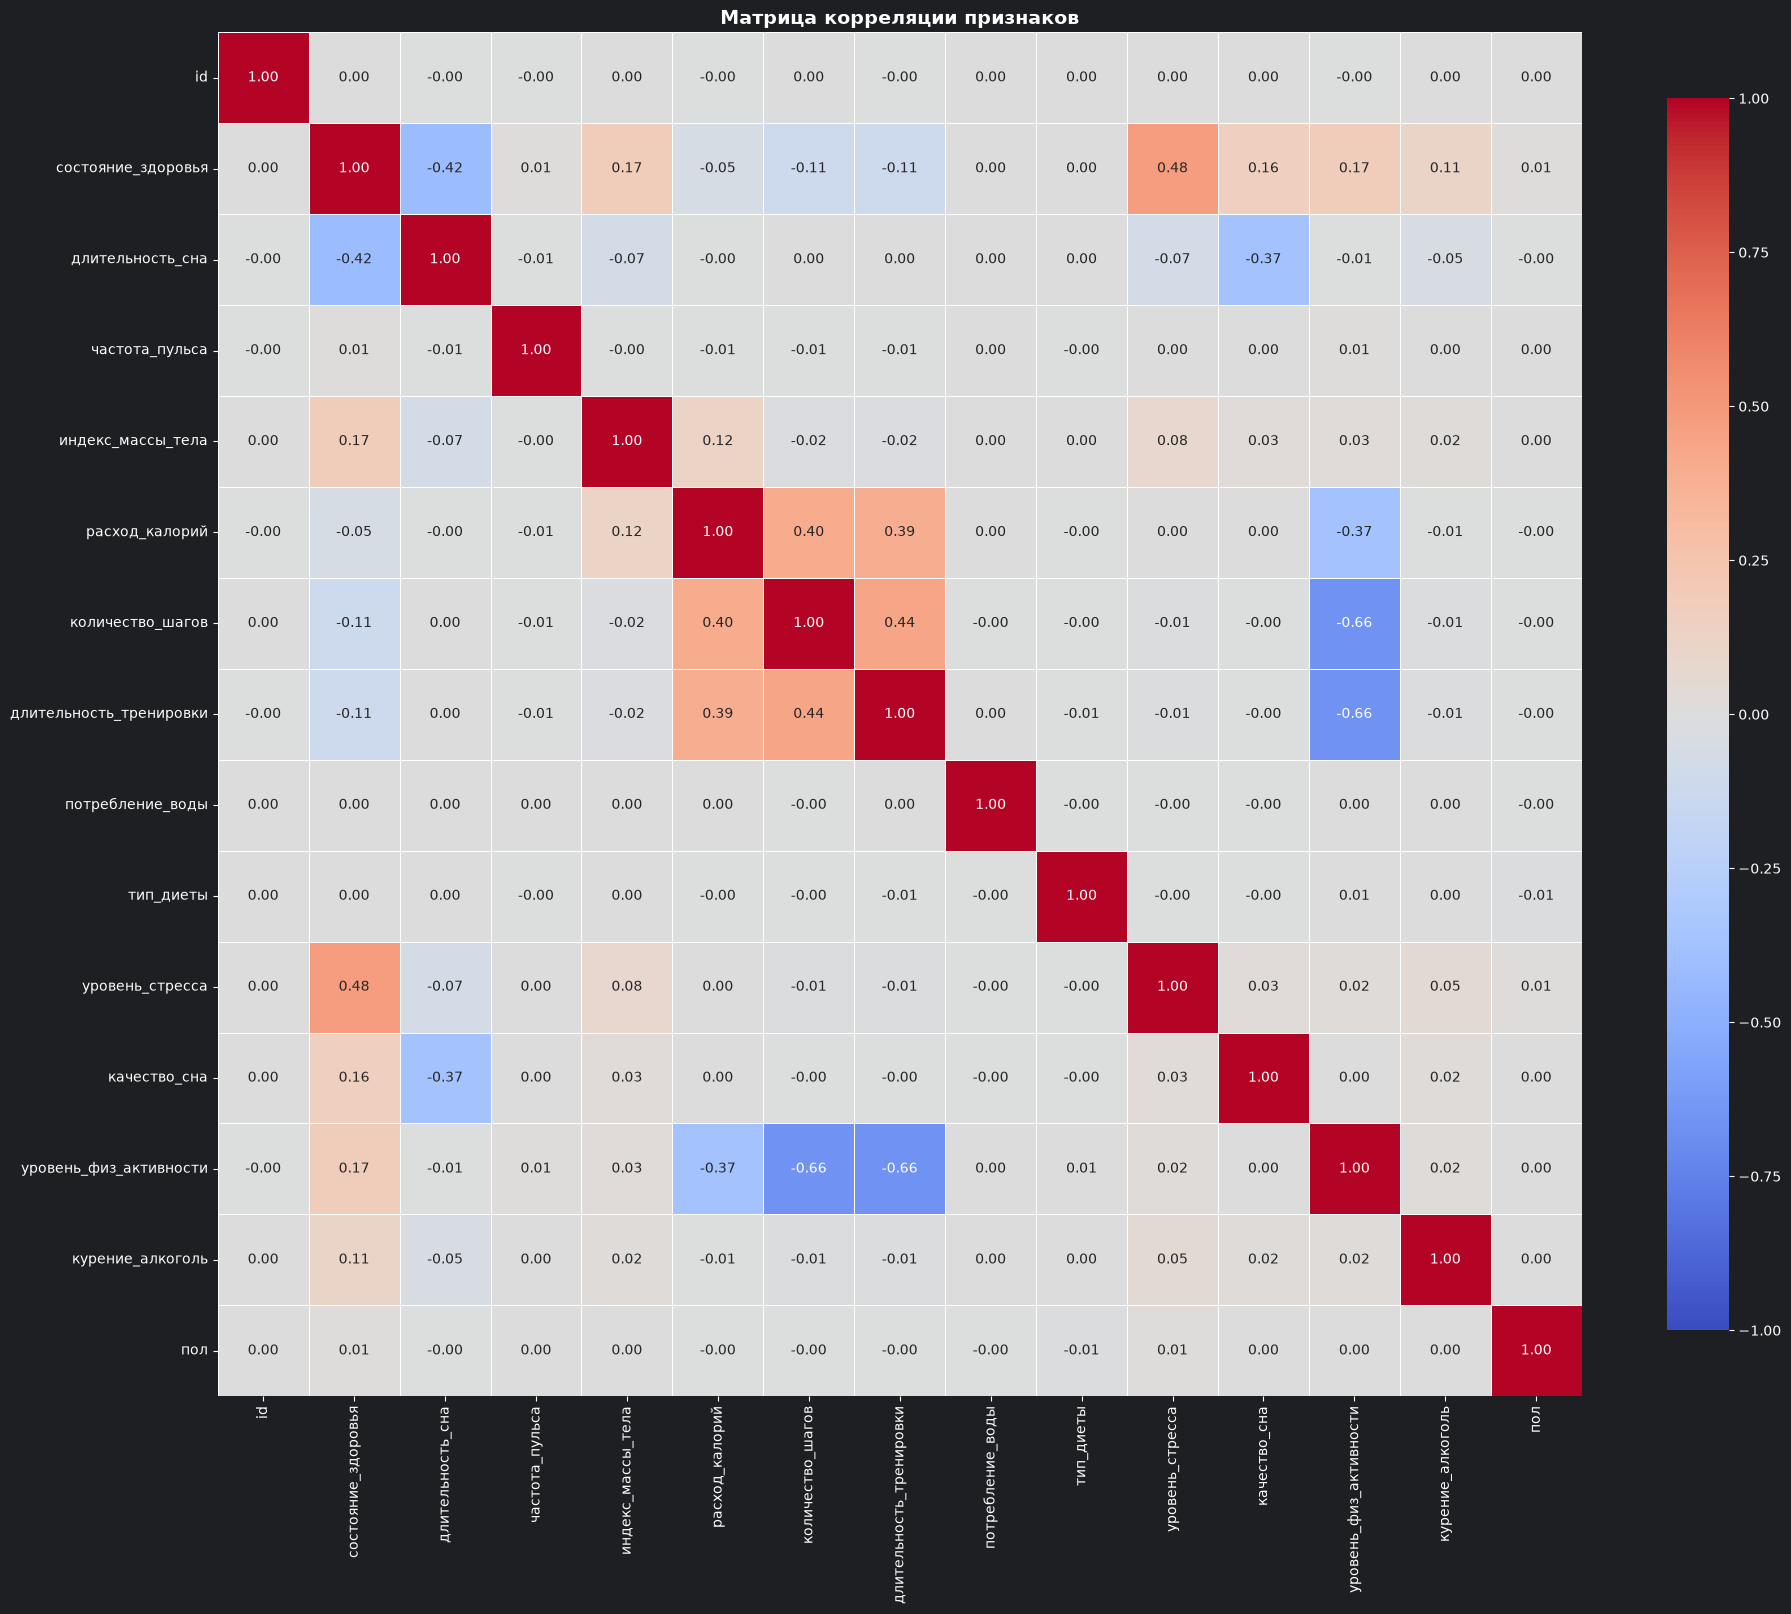

In [3]:
from imputer_corr_matrix import correlation_matrix # imputer_corr_matrix c отдельного файла
matrix = correlation_matrix(df)


# бины по длительность_сна и индекс_массы_тела

In [4]:


def sleep_group(x):
    if pd.isna(x):
        return 'missing'
    elif x < 6:
        return 'short'
    elif x < 7:
        return 'normal'
    elif x < 7.3:
        return 'good'
    else:
        return 'excellent'

df['sleep_group'] = df['длительность_сна'].apply(sleep_group)
df_test['sleep_group'] = df_test['длительность_сна'].apply(sleep_group)

def bmi_group(x):
    if pd.isna(x):
        return 'missing'
    elif x < 20:
        return "low"
    elif x < 26:
        return "middle"
    else:
        return "high"
df['bmi_group'] = df['индекс_массы_тела'].apply(bmi_group)
df_test['bmi_group'] = df_test['индекс_массы_тела'].apply(bmi_group)

# добавляем фичи

In [7]:
categorical_cols = ['тип_диеты', 'уровень_стресса', 'качество_сна',
       'уровень_физ_активности', 'курение_алкоголь', 'пол', 'sleep_group',
       'bmi_group']

df['double_NaN_длит_стрес'] = (df['длительность_сна'].isna() & df['уровень_стресса'].isna()).astype(int)
df_test['double_NaN_длит_стрес'] = (df_test['длительность_сна'].isna() & df_test['уровень_стресса'].isna()).astype(int)

df[categorical_cols] = df[categorical_cols].fillna('None')
df_test[categorical_cols] = df_test[categorical_cols].fillna('None')

df['sleep_state'] = (
    df['sleep_group'].astype(str)
    + "_"
    + df['качество_сна'].astype(str)
)
df_test['sleep_state'] = (
    df_test['sleep_group'].astype(str)
    + '_'
    + df_test['качество_сна'].astype(str)
)
df['sleep_stress'] = (
    df['sleep_group'].astype(str) + "_" + df['уровень_стресса'].astype(str))

df_test['sleep_stress'] = (df_test['sleep_group'].astype(str) + '_' + df_test['уровень_стресса'].astype(str))

def feature(df):
    df = df.copy()
    df['sleep_bmi_stress'] = (df['sleep_group'].astype(str) + '_' + df['bmi_group'].astype(str) + '_' + df['уровень_стресса'].astype(str))

    df["bad_sleep_stress"] = ((df["длительность_сна"] < 6.11) & (df["уровень_стресса"] == 'high')).astype(int)
    df['уровень_стресса_nums'] = df['уровень_стресса'].map({'low':1, 'medium':2, 'high':3})
    df['уровень_физ_активности_nums'] = df['уровень_физ_активности'].map({'active':1, 'moderate':2, 'sedentary':3, 'nan':-1})

    df = df.drop(['уровень_физ_активности_nums', 'уровень_стресса_nums'], axis=1)

    df['bim_stress'] = (df['уровень_стресса'].astype(str) + '_' + df['bmi_group'].astype(str))
    df['bim_ур_физ_фктивн'] = (df['уровень_физ_активности'].astype(str) + '_' + df['bmi_group'].astype(str))
    df['bim_качество_сна'] = (df['качество_сна'].astype(str) + '_' + df['bmi_group'].astype(str))
    df['стресс_активность'] = (df['уровень_физ_активности'].astype(str) + '_' + df['уровень_стресса'].astype(str))
    df['диета_активность'] = (df['уровень_физ_активности'].astype(str) + '_' + df['тип_диеты'].astype(str))
    df['стресс_сон'] = (df['уровень_стресса'].astype(str) + '_' + df['качество_сна'].astype(str))
    df['сон_имт'] = (df['sleep_group'].astype(str) + '_' + df['bmi_group'].astype(str))
    df['health_score'] = 0
    df['health_score'] += (df['длительность_сна'].between(7,8)).astype(int)
    df['health_score'] += (df['индекс_массы_тела'].between(18.5,25)).astype(int)
    df['health_score'] += (df['длительность_тренировки'] > 40).astype(int)
    df['health_score'] += (df['количество_шагов'] > 10000).astype(int)
    df['health_score'] += (df['качество_сна']=='good').astype(int)
    df['risk_score'] = 0
    df['risk_score'] += (df['длительность_сна'] < 6).astype(int)
    df['risk_score'] += (df['индекс_массы_тела'] > 25).astype(int)
    df['risk_score'] += (df['качество_сна']=='poor').astype(int)
    df['risk_score'] += (df['уровень_физ_активности']=='sedentary').astype(int)
    df['курение_стресс'] = (df['курение_алкоголь'].astype(str) + '_' + df['уровень_стресса'].astype(str))
    df['курение_сон'] = (df['курение_алкоголь'].astype(str) + '_' + df['sleep_group'].astype(str))
    df['курение_кач_сна'] = (df['курение_алкоголь'].astype(str) + '_' + df['качество_сна'].astype(str))
    df['курение_имт'] = (df['курение_алкоголь'].astype(str) + '_' + df['bmi_group'].astype(str))
    return df

df = feature(df)
df_test = feature(df_test)


# обучаем катбуст

In [9]:
# КАТБУСТ

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from catboost import CatBoostClassifier

# признаки и цель
df = df.rename(columns={'состояние_здоровья': 'health_condition'})
df_test = df_test.rename(columns = {'состояние_здоровья': 'health_condition'})

X = df.drop(columns=['id', 'health_condition'])
y = df['health_condition']

X_test = df_test.drop(columns=['id'])

categorical_cols = X.select_dtypes(include = [str]).columns.tolist()
# кросс-валидация
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []
models = []
# OOF-предсказания
oof_pred = np.empty(len(X), dtype=object)
oof_proba = np.empty((len(X), 3))
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):

    print(f'Fold {fold}')

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(


        iterations=12000,
        learning_rate=0.011,
        depth=4,
        loss_function='MultiClass',
        auto_class_weights='Balanced',
        task_type='GPU',
        random_seed=42,
        verbose=100
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=categorical_cols,
        use_best_model=True,
        early_stopping_rounds=300
    )
    models.append(model)

    pred = model.predict(X_valid).ravel()
    oof_pred[valid_idx] = pred

    proba = model.predict_proba(X_valid)
    oof_proba[valid_idx] = proba

    score = balanced_accuracy_score(y_valid, pred)

    scores.append(score)

    print(f'Balanced accuracy = {score:.5f}')

test_proba = np.zeros((len(X_test), 3))

for model in models:
    test_proba += model.predict_proba(X_test)

test_proba /= len(models)

test_pred = test_proba.argmax(axis=1)
test_pred = model.classes_[test_proba.argmax(axis=1)]
oof_pred_cat = oof_pred
print('-' * 40)
print(f'Средняя: {np.mean(scores):.5f}')
print(f'Std    : {np.std(scores):.5f}')

print('\nOOF score:', balanced_accuracy_score(y, oof_pred))



Fold 1
0:	learn: 1.0823040	test: 1.0822745	best: 1.0822745 (0)	total: 55.9ms	remaining: 11m 10s
100:	learn: 0.4038734	test: 0.4012263	best: 0.4012263 (100)	total: 849ms	remaining: 1m 39s
200:	learn: 0.2523697	test: 0.2487450	best: 0.2487450 (200)	total: 1.69s	remaining: 1m 39s
300:	learn: 0.2111309	test: 0.2069143	best: 0.2069143 (300)	total: 2.52s	remaining: 1m 38s
400:	learn: 0.1962364	test: 0.1919928	best: 0.1919928 (400)	total: 3.39s	remaining: 1m 38s
500:	learn: 0.1892530	test: 0.1851561	best: 0.1851561 (500)	total: 4.24s	remaining: 1m 37s
600:	learn: 0.1854143	test: 0.1815361	best: 0.1815361 (600)	total: 5.04s	remaining: 1m 35s
700:	learn: 0.1828922	test: 0.1792054	best: 0.1792054 (700)	total: 5.91s	remaining: 1m 35s
800:	learn: 0.1810629	test: 0.1775919	best: 0.1775919 (800)	total: 6.77s	remaining: 1m 34s
900:	learn: 0.1798252	test: 0.1765226	best: 0.1765226 (900)	total: 7.63s	remaining: 1m 34s
1000:	learn: 0.1787179	test: 0.1755836	best: 0.1755836 (1000)	total: 8.51s	remaining:

In [10]:

#СОХРАНЯЕМ РЕЗУЛЬТАТЫ ТЕСТА ДЛЯ КАТБУСТА

test_ids = df_test['id'].copy()
submission = pd.DataFrame({
    'id': test_ids,
    'health_condition': test_pred
})
submission.to_csv('proba_new.csv', index=False)
print("Файл 'proba_new.csv' успешно создан")

Файл 'proba_new.csv' успешно создан


# обучаем lgb

In [11]:
# LGB

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from lightgbm import LGBMClassifier

# признаки и цель

X = df.drop(columns=['id', 'health_condition'])
y = df['health_condition']

X_test = df_test.drop(columns=['id'])

X_lgb = X.copy()
X_test_lgb = X_test.copy()

X_lgb[categorical_cols] = X_lgb[categorical_cols].astype('category')
X_test_lgb[categorical_cols] = X_test_lgb[categorical_cols].astype('category')
# кросс-валидация
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

oof_pred_lgb = np.empty(len(X_lgb), dtype=object)
oof_proba_lgb = np.zeros((len(X_lgb), 3))
test_proba_lgb = np.zeros((len(X_test_lgb), 3))
for fold, (train_idx, valid_idx) in enumerate(cv.split(X_lgb, y), start=1):

    print(f'Fold {fold}')

    X_train = X_lgb.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X_lgb.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = LGBMClassifier(
    n_estimators=850,
    random_state=42,
    class_weight='balanced',
    device='gpu',
    learning_rate=0.013650223499929707,
    num_leaves = 88,
    max_depth = 3,
    min_child_samples = 33,
    early_stopping_rounds=300,
    verbose=100

)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric= 'multi_error'
    )
    test_proba_lgb += model.predict_proba(X_test_lgb) / cv.n_splits
    pred = model.predict(X_valid).ravel()

    oof_pred_lgb[valid_idx] = pred

    proba = model.predict_proba(X_valid)
    oof_proba_lgb[valid_idx] = proba

    score = balanced_accuracy_score(y_valid, pred)

    scores.append(score)

    print(f'Balanced accuracy = {score:.5f}')

test_pred = model.classes_[test_proba_lgb.argmax(axis=1)]
print('-' * 40)
print(f'Средняя: {np.mean(scores):.5f}')
print(f'Std    : {np.std(scores):.5f}')
print('\nOOF score:', balanced_accuracy_score(y, oof_pred_lgb))

Fold 1
[LightGBM] [Warning] early_stopping_round is set=300, early_stopping_rounds=300 will be ignored. Current value: early_stopping_round=300
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.843252
[LightGBM] [Info] Total Bins 2141
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 32
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080 Ti Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 30 dense feature groups (16.85 MB) transferred to GPU in 0.016463 secs. 1 sparse feature groups
[LightGBM] [Warning] early_stopping_round is set=300, early_stopping_rounds=300 will be ignored. Current value: early_stopping_round=300
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from scor

In [12]:
# СМОТРИМ ВНОСИТ ЛИ РАЗНОСТЬ В ОТВЕТАХ ДРУГАЯ МОДЕЛЬ

diff = (oof_pred != oof_pred_lgb)

print(f'Различаются: {diff.mean():.2%}')
cat_correct = (oof_pred == y)
lgb_correct = (oof_pred_lgb == y)
both_correct = cat_correct & lgb_correct
print("Обе верны:", both_correct.sum())
both_wrong = (~cat_correct) & (~lgb_correct)
print("Обе ошиблись:", both_wrong.sum())
only_cat = cat_correct & (~lgb_correct)
print("Только CatBoost:", only_cat.sum())
only_lgb = (~cat_correct) & lgb_correct
print("Только LightGBM:", only_lgb.sum())

Различаются: 1.04%
Обе верны: 643970
Обе ошиблись: 39305
Только CatBoost: 3864
Только LightGBM: 2949


# подготовка данных для etc

In [13]:
# ETC ПОДГОТОВКА ДАННЫХ

df_etc = pd.read_csv('D:/Dataset/dataset_schule/df_complete/train.csv')
df_test_etc = pd.read_csv('D:/Dataset/dataset_schule/df_complete/test.csv')
dicts = {
    'health_condition': 'состояние_здоровья',
    'sleep_duration': 'длительность_сна',
    'heart_rate': 'частота_пульса',
    'bmi': 'индекс_массы_тела',
    'calorie_expenditure': 'расход_калорий',
    'step_count': 'количество_шагов',
    'exercise_duration': 'длительность_тренировки',
    'water_intake': 'потребление_воды',
    'diet_type': 'тип_диеты',
    'stress_level': 'уровень_стресса',
    'sleep_quality': 'качество_сна',
    'physical_activity_level': 'уровень_физ_активности',
    'smoking_alcohol': 'курение_алкоголь',
    'gender': 'пол'
}
df_etc = df_etc.rename(columns = dicts)
df_test_etc = df_test_etc.rename(columns = dicts)

df_etc['double_missing'] = (
    df_etc['длительность_сна'].isna() &
    df_etc['уровень_стресса'].isna()
).astype(int)


df_test_etc['double_missing'] = (
    df_test_etc['длительность_сна'].isna() &
    df_test_etc['уровень_стресса'].isna()
).astype(int)
df_etc['sleep_missing'] = df_etc['длительность_сна'].isnull().astype(int)
df_test_etc['sleep_missing'] = df_test_etc['длительность_сна'].isnull().astype(int)
df_etc['stress_missing'] = df_etc['уровень_стресса'].isnull().astype(int)
df_test_etc['stress_missing'] = df_test_etc['уровень_стресса'].isnull().astype(int)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


numeric_features = ['длительность_сна', 'частота_пульса', 'индекс_массы_тела', 'расход_калорий', 'количество_шагов', 'длительность_тренировки', 'потребление_воды', 'sleep_missing', 'stress_missing', 'double_missing']

categorical_features = ['тип_диеты','уровень_стресса', 'качество_сна', 'уровень_физ_активности', 'курение_алкоголь', 'пол']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore'))]),categorical_features
        )
    ]
)

X_etc = df_etc.drop(columns=['id', 'состояние_здоровья'])
y_etc = df_etc['состояние_здоровья']

X_test_etc = df_test_etc.drop(columns=['id'])

# обучаем etc

In [14]:
# ETC

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.ensemble import ExtraTreesClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba_etc = np.zeros((len(X_etc), 3))
test_proba_etc = np.zeros((len(X_test_etc), 3))

models_etc = []
scores = []


# Обучение

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_etc, y_etc), start=1):

    print(f'\nFold {fold}')

    X_train = X_etc.iloc[train_idx]
    y_train = y_etc.iloc[train_idx]

    X_valid = X_etc.iloc[valid_idx]
    y_valid = y_etc.iloc[valid_idx]

    X_train_ready = preprocessor.fit_transform(X_train)
    X_valid_ready = preprocessor.transform(X_valid)

    model = ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_ready, y_train)
    models_etc.append(model)

    valid_proba = model.predict_proba(X_valid_ready)
    oof_proba_etc[valid_idx] = valid_proba

    pred = model.classes_[valid_proba.argmax(axis=1)]
    score = balanced_accuracy_score(y_valid,pred)
    scores.append(score)

    print(f'Balanced accuracy: {score:.5f}')

print('-'*40)
print('Mean:', np.mean(scores))
print('STD:',np.std(scores))

# OOF score
classes_etc = models_etc[0].classes_
oof_pred_etc = classes_etc[oof_proba_etc.argmax(axis=1)]

print('OOF:', balanced_accuracy_score( y_etc, oof_pred_etc))

# TEST prediction
X_all_ready = preprocessor.fit_transform(X_etc)
X_test_ready = preprocessor.transform(X_test_etc)

models_etc_final = []

for seed in range(5):

    model = ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=seed,
        n_jobs=-1
    )
    print(f"обучение финальной модели на всех данных. фолд: {seed+1}")
    model.fit(X_all_ready, y_etc)
    models_etc_final.append(model)

test_proba_etc = np.zeros((len(X_test_etc),3))

for model in models_etc_final:
    test_proba_etc += model.predict_proba(X_test_ready)/5

classes_etc = models_etc_final[0].classes_
test_pred_etc = classes_etc[test_proba_etc.argmax(axis=1)]

print(test_pred_etc[:10])


Fold 1
Balanced accuracy: 0.92687

Fold 2
Balanced accuracy: 0.92842

Fold 3
Balanced accuracy: 0.92643

Fold 4
Balanced accuracy: 0.92681

Fold 5
Balanced accuracy: 0.92469
----------------------------------------
Mean: 0.9266441847264109
STD: 0.0011916165493477322
OOF: 0.926644254194223
обучение финальной модели на всех данных. фолд: 1
обучение финальной модели на всех данных. фолд: 2
обучение финальной модели на всех данных. фолд: 3
обучение финальной модели на всех данных. фолд: 4
обучение финальной модели на всех данных. фолд: 5
['unhealthy' 'unhealthy' 'at-risk' 'at-risk' 'unhealthy' 'fit' 'unhealthy'
 'at-risk' 'at-risk' 'at-risk']


СТЕКИНГ МЕТА МОДЕЛЬ

In [19]:
# СТЕКИНГ МЕТА МОДЕЛЬ

from sklearn.linear_model import LogisticRegression

X_stack = np.hstack([oof_proba, oof_proba_lgb, oof_proba_etc])
y_stack = df['health_condition']

X_stack_test = np.hstack([test_proba, test_proba_lgb, test_proba_etc])

cv = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

test_proba_all = np.zeros((len(X_stack_test),3))
predicts = []
scores = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_stack, y_stack), start=1):
    print(f'\nFold {fold}')

    X_train = X_stack[train_idx]
    y_train = y_stack[train_idx]

    X_valid = X_stack[valid_idx]
    y_valid = y_stack[valid_idx]

    model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1)
    model.fit(X_train, y_train)

    test_proba_all += model.predict_proba(X_stack_test) / cv.n_splits


    pred = model.predict(X_valid)
    predicts.append(pred)

    score = balanced_accuracy_score(y_valid, pred)
    scores.append(score)

    print(f'Balanced accuracy = {score:.5f}')

print(np.mean(scores))

classes_all = models[0].classes_
predicts_test = classes_all[test_proba_all.argmax(axis = 1)]
print(predicts_test[:10])


Fold 1
Balanced accuracy = 0.94978

Fold 2
Balanced accuracy = 0.95130

Fold 3
Balanced accuracy = 0.94898

Fold 4
Balanced accuracy = 0.94886

Fold 5
Balanced accuracy = 0.94750
0.9492856344876811
['unhealthy' 'unhealthy' 'at-risk' 'at-risk' 'unhealthy' 'fit' 'at-risk'
 'at-risk' 'at-risk' 'at-risk']


ОШИБКИ ПО МЕТРИКАМ

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y, oof_pred)
#print(cm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
#
cm_norm = pd.DataFrame(
    cm_norm,
    index=model.classes_,
    columns=model.classes_
)
print(cm_norm)

print(classification_report(y, oof_pred))

            at-risk       fit  unhealthy
at-risk    0.935669  0.023064   0.041267
fit        0.045273  0.949401   0.005326
unhealthy  0.032448  0.004279   0.963274
              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    592561
         fit       0.73      0.95      0.83     39803
   unhealthy       0.69      0.96      0.81     57724

    accuracy                           0.94    690088
   macro avg       0.81      0.95      0.87    690088
weighted avg       0.95      0.94      0.94    690088



In [31]:

#СОХРАНЯЕМ РЕЗУЛЬТАТЫ ТЕСТА

test_ids = df_test['id'].copy()
submission = pd.DataFrame({
    'id': test_ids,
    'health_condition': predicts_test
})

submission.to_csv('predict_new_all.csv', index=False)
print("Файл успешно создан")

Файл успешно создан
